# Group 7 - Public Policy and Resource Allocation

**CC2017 Modelacion y Simulacion - Ciudad UVG earthquake scenario**

This notebook is the complete, self-contained deliverable for Group 7: it
builds the model, runs the Monte Carlo simulation, evaluates the four policy
metrics, integrates the in-person exchange reports (Groups 2, 3, 5), and
produces the exam's required closing output (a 72-hour resource allocation
plan, its quantitative justification, its evaluation against the four
metrics, and a sensitivity analysis).

There is no separate `src/` package: every function, dataclass, and
constant used below is defined directly in this notebook, in the order the
report/video narrative needs them.

In [1]:
import sys
from dataclasses import dataclass, field, replace
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# This notebook lives at <project_root>/notebooks/main.ipynb.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

print(f"Project root: {PROJECT_ROOT}")
print(f"Python: {sys.version}")

Project root: /home/jonialen/Documents/uvg/s8/mod/examenP1
Python: 3.12.13 (main, Jun 23 2026, 15:18:55) [Clang 22.1.3 ]


## 1. Constants

Scenario structure fixed by the assignment statement (5 zones, 72-hour
horizon split into 12 six-hour blocks), plus the resource catalog and
Monte Carlo defaults. Nothing in this cell depends on the Excel file - it
comes directly from the assignment text.

In [2]:
ZONES = ["Z1", "Z2", "Z3", "Z4", "Z5"]
N_ZONES = len(ZONES)

N_BLOCKS = 12
HOURS_PER_BLOCK = 6
HORIZON_HOURS = 72
assert N_BLOCKS * HOURS_PER_BLOCK == HORIZON_HOURS

# Source: docs/Grupo7_PoliticaPublica.xlsx, section "1. RECURSOS DISPONIBLES
# PARA ASIGNACION". These are the group's own 8 resource line items - do NOT
# invent generic categories here.
RESOURCE_TYPES = [
    "presupuesto_municipal",
    "presupuesto_nacional",
    "vehiculos_pesados",
    "vehiculos_distribucion",
    "generadores",
    "combustible",
    "kits_agua",
    "tiendas_campana",
]
N_RESOURCES = len(RESOURCE_TYPES)
BUDGET_RESOURCES = ["presupuesto_municipal", "presupuesto_nacional"]
PHYSICAL_RESOURCES = [r for r in RESOURCE_TYPES if r not in BUDGET_RESOURCES]

DEFAULT_SEED = 42
# The assignment requires >= 30 replications; 300 gives materially tighter
# 95% CIs while still running fast.
N_REPLICATIONS = 300
ASSIGNMENT_MIN_REPLICATIONS = 30
CI_LEVEL = 0.95

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_EXCHANGE = PROJECT_ROOT / "data" / "exchange"
DOCS_DIR = PROJECT_ROOT / "docs"
OUTPUTS = PROJECT_ROOT / "outputs"
OUTPUTS.mkdir(exist_ok=True)

EXCEL_PATH = DOCS_DIR / "Grupo7_PoliticaPublica.xlsx"


def block_to_hours(block: int) -> tuple[int, int]:
    """Return the (start_hour, end_hour) window covered by a 1-indexed block."""
    if not (1 <= block <= N_BLOCKS):
        raise ValueError(f"block must be in [1, {N_BLOCKS}], got {block}")
    return (block - 1) * HOURS_PER_BLOCK, block * HOURS_PER_BLOCK


# First-24-hours convenience: blocks 1-4 (used by Question 1).
FIRST_24H_BLOCKS = [b for b in range(1, N_BLOCKS + 1) if block_to_hours(b)[1] <= 24]
print("Resource types:", RESOURCE_TYPES)
print("First-24h blocks:", FIRST_24H_BLOCKS)

Resource types: ['presupuesto_municipal', 'presupuesto_nacional', 'vehiculos_pesados', 'vehiculos_distribucion', 'generadores', 'combustible', 'kits_agua', 'tiendas_campana']
First-24h blocks: [1, 2, 3, 4]


## 2. Paradigm justification (draft - edit for the final report)

**Paradigm: System Dynamics (aggregate stock-and-flow) + a scheduled
decision/control layer.**

- The object of study is the *aggregate* resource pool, unmet need, and
  backlog **per zone**, not individual people, vehicles, or decision-makers.
  That rules out an Agent-Based Model: no individually distinguishable agent
  is the unit of analysis here (contrast with Group 6, whose object of study
  *is* individual evacuation behavior).
- There is no discrete-entity queueing discipline (no explicit arrival
  process, service times, or queue of individually tracked entities), which
  rules out Discrete-Event Simulation.
- What the model *does* need is: (a) stocks that persist and evolve over
  time with explicit inflows/outflows - the resource endowment depletes
  block by block, and unmet need accumulates into a backlog stock with
  carryover and urgency growth (the classic SD feedback loop); and (b) a
  decision that is re-evaluated on a fixed schedule (every 6-hour block),
  not triggered by discrete events - this is the "scheduled control layer"
  on top of the SD core.
- **Boundary:** the control layer (the allocation policy) is a scheduled
  decision, not an autonomous agent's individual choice, so it stays inside
  the SD + control-layer paradigm rather than crossing into ABM.

TODO (Group 7, for the report): restate this using the exact selection
criteria from the lecture slides (state representation, time
representation, entity granularity), and cite the specific slide/criterion
that rules out ABM and DES for this component.

## 3. Excel inspection and parsing

`docs/Grupo7_PoliticaPublica.xlsx` (sheet `Datos_Grupo7`) already arrived.
It is a single sheet in a **section-block layout** (not a clean table): each
numbered section header row is followed by its own header row and data
rows. The cell below (a) prints a generic schema dump (shape/columns/head -
useful for the group if a *new* file arrives later), then (b) parses the
known section layout of this specific file and cross-checks the parsed
values against the hardcoded constants used in Section 4, so the notebook
proves it reads the file correctly. Both steps degrade gracefully (print a
message, do not raise) if the file is ever moved or missing.

In [3]:
def describe_workbook(path=None):
    """Print sheet names, shapes, columns, dtypes, and head for an Excel workbook.

    If `path` is None, look for `EXCEL_PATH` first, then any .xlsx in
    data/raw/. Prints a clear message instead of raising if nothing is found.
    """
    if path is None:
        if EXCEL_PATH.exists():
            path = EXCEL_PATH
        else:
            candidates = sorted(DATA_RAW.glob("*.xlsx"))
            if not candidates:
                print(f"No .xlsx file found at {EXCEL_PATH} or in {DATA_RAW}.")
                print("Drop the Group 7 Excel file there, then re-run this cell.")
                return None
            path = candidates[0]
    path = Path(path)
    sheets = pd.read_excel(path, sheet_name=None, header=None, engine="openpyxl")
    print(f"Workbook: {path}")
    print(f"Sheets found: {len(sheets)}")
    for name, df in sheets.items():
        print("=" * 72)
        print(f"Sheet: {name!r}  shape={df.shape}")
        print(df.head(10))
        print()
    return sheets


_ = describe_workbook()

Workbook: /home/jonialen/Documents/uvg/s8/mod/examenP1/docs/Grupo7_PoliticaPublica.xlsx
Sheets found: 1
Sheet: 'Datos_Grupo7'  shape=(48, 5)
                                                   0          1  \
0  EXAMEN PRÁCTICO — SEMANA 10 | Ciudad UVG — Ter...        NaN   
1  GRUPO 7: Política Pública y Asignación de Recu...        NaN   
2  Fuente: datos sintéticos calibrados con paráme...        NaN   
3                                                NaN        NaN   
4  1. RECURSOS DISPONIBLES PARA ASIGNACIÓN (presu...        NaN   
5                                            Recurso     Unidad   
6                   Presupuesto emergencia municipal  Quetzales   
7                    Presupuesto emergencia nacional  Quetzales   
8               Vehículos pesados (retroexcavadoras)   unidades   
9                          Vehículos de distribución   unidades   

               2                   3                                4  
0            NaN                 NaN             

In [4]:
def parse_grupo7_workbook(path=EXCEL_PATH):
    """Parse the section-block layout of docs/Grupo7_PoliticaPublica.xlsx.

    The sheet has no single header row: it is a sequence of numbered
    section titles ("1. RECURSOS...", "2. NIVELES DE DAÑO...", etc.), each
    followed by its own header row and data rows. This function locates
    each section by matching the start of its title text in column 0, then
    slices out the table beneath it.

    Returns a dict with keys "resources", "zones", "metrics" (DataFrames),
    or None if the file is not present.
    """
    path = Path(path)
    if not path.exists():
        print(f"{path} not found - skipping Excel parsing (using hardcoded Params instead).")
        return None

    raw = pd.read_excel(path, sheet_name="Datos_Grupo7", header=None, engine="openpyxl")
    col0 = raw[0].astype(str)

    def section_start(prefix):
        matches = col0[col0.str.startswith(prefix)]
        if matches.empty:
            raise ValueError(f"Section starting with {prefix!r} not found in {path}")
        return matches.index[0]

    resources_start = section_start("1. RECURSOS")
    zones_start = section_start("2. NIVELES DE DA")
    metrics_start = section_start("4. M")

    # Resources table: header row is resources_start + 1, data rows follow
    # until the first fully-empty row.
    resources_header_row = resources_start + 1
    resources_rows = []
    r = resources_header_row + 1
    while r < len(raw) and pd.notna(raw.iloc[r, 0]):
        resources_rows.append(raw.iloc[r].tolist())
        r += 1
    resources_df = pd.DataFrame(
        resources_rows,
        columns=["recurso", "unidad", "disponible_t0", "costo_unitario_q", "fuente"],
    )

    zones_header_row = zones_start + 1
    zones_rows = []
    r = zones_header_row + 1
    while r < len(raw) and pd.notna(raw.iloc[r, 0]):
        zones_rows.append(raw.iloc[r].tolist())
        r += 1
    zones_df = pd.DataFrame(
        zones_rows,
        columns=["zona", "indice_dano", "poblacion_en_riesgo", "prioridad", "justificacion"],
    )

    metrics_header_row = metrics_start + 1
    metrics_rows = []
    r = metrics_header_row + 1
    while r < len(raw) and pd.notna(raw.iloc[r, 0]):
        metrics_rows.append(raw.iloc[r, :4].tolist())
        r += 1
    metrics_df = pd.DataFrame(
        metrics_rows, columns=["metrica", "definicion", "umbral", "peso"]
    )

    return {"resources": resources_df, "zones": zones_df, "metrics": metrics_df}


parsed = parse_grupo7_workbook()

if parsed is not None:
    print("Parsed resources table:")
    print(parsed["resources"])
    print()
    print("Parsed zones table:")
    print(parsed["zones"])
    print()
    print("Parsed metrics table:")
    print(parsed["metrics"])

Parsed resources table:
                                  recurso     unidad  disponible_t0  \
0        Presupuesto emergencia municipal  Quetzales        8500000   
1         Presupuesto emergencia nacional  Quetzales       32000000   
2    Vehículos pesados (retroexcavadoras)   unidades             12   
3               Vehículos de distribución   unidades             57   
4               Generadores de emergencia   unidades             18   
5                             Combustible    galones           8400   
6     Kits de agua potable (purificación)       kits           2800   
7  Tiendas de campaña (albergue temporal)   unidades            420   

   costo_unitario_q                           fuente  
0                 1    Fondo municipal contingencias  
1                 1          SE-CONRED / Presidencia  
2             18000  Municipalidad + empresa privada  
3              2500            Flota municipal + ONG  
4              8500       Reserva estratégica CONRED  
5     

In [5]:
def verify_parsed_against_hardcoded(parsed):
    """Soft-verify the parsed workbook against the hardcoded Params constants
    defined in Section 4. Prints PASS/WARN per check rather than raising, so
    the notebook still runs end to end even if the file changes slightly.
    """
    if parsed is None:
        print("Skipping verification: workbook was not parsed.")
        return

    checks = []
    checks.append(("5 zones parsed", len(parsed["zones"]) == 5))
    checks.append(("8 resources parsed", len(parsed["resources"]) == 8))
    checks.append(("4 metrics parsed", len(parsed["metrics"]) == 4))

    z1_row = parsed["zones"][parsed["zones"]["zona"].str.startswith("Z1")]
    if not z1_row.empty:
        checks.append(("Z1 damage index == 8.4", float(z1_row.iloc[0]["indice_dano"]) == 8.4))
        checks.append(
            ("Z1 population_at_risk == 28400", int(z1_row.iloc[0]["poblacion_en_riesgo"]) == 28_400)
        )

    muni_row = parsed["resources"][parsed["resources"]["recurso"].str.contains("municipal", case=False)]
    if not muni_row.empty:
        checks.append(
            ("Municipal budget T0 == 8,500,000", float(muni_row.iloc[0]["disponible_t0"]) == 8_500_000.0)
        )

    for label, ok in checks:
        print(f"[{'PASS' if ok else 'WARN'}] {label}")


verify_parsed_against_hardcoded(parsed)

[PASS] 5 zones parsed
[PASS] 8 resources parsed
[PASS] 4 metrics parsed
[PASS] Z1 damage index == 8.4
[PASS] Z1 population_at_risk == 28400
[PASS] Municipal budget T0 == 8,500,000


## 4. Model parameters (`Params`)

All values below are transcribed directly from
`docs/Grupo7_PoliticaPublica.xlsx` **except** where explicitly marked
`# ASSUMPTION:` - the Excel file gives resource stocks, zone damage, policy
constraints, and metric definitions, but it does NOT give per-capita need
rates or a mortality submodel. The assignment explicitly allows documented
additional assumptions when the source file is incomplete
("Los datos de su archivo Excel son el punto de partida... puede hacer
supuestos adicionales siempre que los documente explicitamente").

In [6]:
PRIORITY_WEIGHT = {"CRITICA": 1.0, "ALTA": 0.75, "MODERADA": 0.5, "BAJA": 0.25}


@dataclass
class MortalityAssumptions:
    """Documented assumptions for the preventable-mortality submodel (metric M1).

    The Excel file does not provide a mortality model. Every constant below
    is an ASSUMPTION the group must revisit and justify (or replace) in the
    final report.
    """

    # ASSUMPTION: base fraction of a zone's at-risk population that becomes
    # a preventable death per 6h block, under zero coverage and zero backlog.
    base_preventable_rate: float = 0.006

    # ASSUMPTION: extra multiplier per unit of the (dimensionless) backlog
    # index, representing compounding urgency the longer needs go unmet.
    backlog_time_penalty_factor: float = 0.5

    def damage_factor(self, damage_index_0_10: float) -> float:
        """ASSUMPTION: linear scaling of the (0-10) damage index to (0-1)."""
        return damage_index_0_10 / 10.0

    def time_penalty(self, backlog_index: float) -> float:
        """ASSUMPTION: linear urgency growth with the dimensionless backlog index."""
        return 1.0 + self.backlog_time_penalty_factor * backlog_index


@dataclass
class Params:
    zones: list = field(default_factory=lambda: list(ZONES))

    zone_name: dict = field(
        default_factory=lambda: {
            "Z1": "Centro historico", "Z2": "Norte residencial", "Z3": "Sur industrial",
            "Z4": "Este comercial", "Z5": "Oeste periferico",
        }
    )

    # Source: docs/Grupo7_PoliticaPublica.xlsx, section
    # "2. NIVELES DE DANO POR ZONA (evaluacion inicial)"
    damage_index: dict = field(
        default_factory=lambda: {"Z1": 8.4, "Z2": 3.1, "Z3": 5.8, "Z4": 2.2, "Z5": 9.1}
    )
    population_at_risk: dict = field(
        default_factory=lambda: {
            "Z1": 28_400, "Z2": 6_800, "Z3": 14_200, "Z4": 4_100, "Z5": 31_400,
        }
    )
    declared_priority: dict = field(
        default_factory=lambda: {
            "Z1": "CRITICA", "Z2": "MODERADA", "Z3": "ALTA", "Z4": "BAJA", "Z5": "CRITICA",
        }
    )
    justification: dict = field(
        default_factory=lambda: {
            "Z1": "Mayor densidad + mayor dano estructural",
            "Z2": "Dano limitado, buena accesibilidad",
            "Z3": "Zona industrial - riesgo de contaminacion",
            "Z4": "Menor dano, mejor infraestructura",
            "Z5": "Mayor dano + mayor vulnerabilidad + peor acceso",
        }
    )

    # Source: docs/Grupo7_PoliticaPublica.xlsx, section
    # "1. RECURSOS DISPONIBLES PARA ASIGNACION"
    resource_unit: dict = field(
        default_factory=lambda: {
            "presupuesto_municipal": "quetzales", "presupuesto_nacional": "quetzales",
            "vehiculos_pesados": "unidades", "vehiculos_distribucion": "unidades",
            "generadores": "unidades", "combustible": "galones",
            "kits_agua": "kits", "tiendas_campana": "unidades",
        }
    )
    resource_available_t0: dict = field(
        default_factory=lambda: {
            "presupuesto_municipal": 8_500_000.0, "presupuesto_nacional": 32_000_000.0,
            "vehiculos_pesados": 12.0, "vehiculos_distribucion": 57.0,
            "generadores": 18.0, "combustible": 8_400.0,
            "kits_agua": 2_800.0, "tiendas_campana": 420.0,
        }
    )
    unit_cost: dict = field(
        default_factory=lambda: {
            "presupuesto_municipal": 1.0, "presupuesto_nacional": 1.0,
            "vehiculos_pesados": 18_000.0, "vehiculos_distribucion": 2_500.0,
            "generadores": 8_500.0, "combustible": 28.0,
            "kits_agua": 120.0, "tiendas_campana": 850.0,
        }
    )
    funding_source: dict = field(
        default_factory=lambda: {
            "presupuesto_municipal": "Fondo municipal contingencias",
            "presupuesto_nacional": "SE-CONRED / Presidencia",
            "vehiculos_pesados": "Municipalidad + empresa privada",
            "vehiculos_distribucion": "Flota municipal + ONG",
            "generadores": "Reserva estrategica CONRED",
            "combustible": "Reserva estrategica",
            "kits_agua": "SESAN / UNICEF",
            "tiendas_campana": "Cruz Roja / CONRED",
        }
    )

    # ASSUMPTION: the Excel file gives total stock available at T0 but no
    # per-capita need rates. These rates are calibrated so that cumulative
    # 12-block need is roughly 2x the fixed T0 stock per resource - i.e.
    # severe but not absurd scarcity (an extreme mismatch would drive every
    # policy's coverage near zero and hide any policy differences).
    baseline_need_per_capita: dict = field(
        default_factory=lambda: {
            "presupuesto_municipal": 17.0, "presupuesto_nacional": 63.0,
            "vehiculos_pesados": 0.00002, "vehiculos_distribucion": 0.00011,
            "generadores": 0.000035, "combustible": 0.0150,
            "kits_agua": 0.0055, "tiendas_campana": 0.0008,
        }
    )

    # SD feedback: backlog carryover / urgency growth. ASSUMPTION (not in Excel).
    backlog_carryover_factor: float = 0.7
    backlog_urgency_growth: float = 1.05

    # ASSUMPTION: access loss derived heuristically from the damage index
    # (more structural damage -> harder physical access). A real
    # accessibility index is Group 4's domain and only reaches Group 7
    # through the exchange - see constraint C4 below.
    @property
    def access_loss_rate(self):
        return {z: min(0.9, self.damage_index[z] / 20.0) for z in self.zones}

    # C4 (coordination constraint): Group 7 does not directly receive
    # Group 4's route-accessibility map, so heavy-vehicle
    # (vehiculos_pesados) delivery is additionally gated by a documented,
    # ASSUMPTION per-zone probability that routes are confirmed accessible
    # this block. This is a modeling limitation, flagged again in the
    # limitations section of the report.
    route_availability_probability: dict = field(
        default_factory=lambda: {"Z1": 0.6, "Z2": 0.9, "Z3": 0.8, "Z4": 0.95, "Z5": 0.5}
    )

    need_coefficient_of_variation: float = 0.15
    delivery_failure_probability: float = 0.10

    mortality: MortalityAssumptions = field(default_factory=MortalityAssumptions)

    # -- Policy constraints, section "3. RESTRICCIONES DE LA POLITICA" ------
    min_rescue_teams_block1_critical: float = 1.0
    equity_max_share: float = 0.40
    equity_min_share_other_critical: float = 0.15
    national_debt_limit_fraction_24h: float = 0.80

    # -- Sensitivity-analysis scenario flags (Section 14b) -------------------
    national_budget_multiplier: float = 1.0  # 0.5 -> halved national budget
    inaccessible_zone: str = None            # e.g. "Z1"
    inaccessible_blocks: tuple = ()          # e.g. (1, 2)

    def __post_init__(self):
        if len(self.zones) != N_ZONES:
            raise ValueError(f"Expected {N_ZONES} zones, got {len(self.zones)}")

    @staticmethod
    def default():
        return Params()


def validate(params):
    """Sanity checks: 5 zones, nonnegative resources, rates in [0, 1]."""
    if sorted(params.zones) != sorted(ZONES):
        raise ValueError(f"Zone labels {params.zones} do not match expected {ZONES}")
    for resource, stock in params.resource_available_t0.items():
        if stock < 0:
            raise ValueError(f"resource_available_t0[{resource}]={stock} is negative")
    for zone, rate in params.access_loss_rate.items():
        if not (0.0 <= rate <= 1.0):
            raise ValueError(f"access_loss_rate[{zone}]={rate} outside [0, 1]")
    for zone, p in params.route_availability_probability.items():
        if not (0.0 <= p <= 1.0):
            raise ValueError(f"route_availability_probability[{zone}]={p} outside [0, 1]")
    if not (0.0 <= params.delivery_failure_probability <= 1.0):
        raise ValueError("delivery_failure_probability outside [0, 1]")
    if not (0.0 <= params.backlog_carryover_factor <= 1.0):
        raise ValueError("backlog_carryover_factor outside [0, 1]")
    print("Params validated OK.")


params = Params.default()
validate(params)
print("Total population at risk:", sum(params.population_at_risk.values()))

Params validated OK.
Total population at risk: 84900


## 5. Allocation policies

This is the control/decision layer: at every block, a policy splits the
available resource pool across the 5 zones. Every policy shares the same
signature: `policy(block, resources, need, backlog, params) -> allocation`
(a length-`N_ZONES` array summing to at most `resources`). This is a
**scheduled** decision (re-evaluated once per block), not an agent-level
decision by an individual actor - see the paradigm note in Section 7.

In [7]:
def _normalize_to_pool(weights, resources):
    """Scale nonnegative weights so they sum to exactly `resources`."""
    total = weights.sum()
    if total <= 0:
        return np.full(N_ZONES, resources / N_ZONES)
    return weights / total * resources


def equal_share(block, resources, need, backlog, params):
    """Split resources equally across zones, ignoring need or damage.

    Rationale: an egalitarian baseline ("administrative simplicity" over
    "targeting efficiency"), useful only as a floor for comparison.
    """
    return np.full(N_ZONES, resources / N_ZONES)


def proportional_to_need(block, resources, need, backlog, params):
    """Split resources proportionally to each zone's raw need this block.

    Rationale: classic demand-driven targeting ("resources follow need"),
    ignoring accumulated backlog and vulnerability.
    """
    return _normalize_to_pool(np.maximum(need, 0.0), resources)


def severity_weighted(block, resources, need, backlog, params):
    """Split resources by a severity score = damage index x declared priority.

    Rationale: prioritizes zones that are both more structurally damaged
    and more urgently classified (CRITICA/ALTA/MODERADA/BAJA), independent
    of raw reported demand - the standard "targeting by need + vulnerability"
    public-policy rationale for prioritizing the worst-hit zones.
    """
    weights = np.array([
        (params.damage_index[z] / 10.0) * PRIORITY_WEIGHT[params.declared_priority[z]]
        for z in ZONES
    ])
    return _normalize_to_pool(weights, resources)


def worst_first(block, resources, need, backlog, params):
    """Give allocation priority to the zone(s) with the largest backlog.

    Rationale: a "fix the worst problem first" triage rule. Directly
    exercises the SD feedback loop: backlog accumulated in earlier blocks
    raises a zone's priority in the current block.
    """
    return _normalize_to_pool(np.maximum(backlog, 0.0), resources)


def threshold_then_proportional(block, resources, need, backlog, params):
    """Guarantee a minimum floor per zone, then distribute the rest by need.

    Rationale: models a "no zone left at zero" political constraint (a
    minimum service guarantee) combined with need-based targeting for the
    remainder. The floor fraction (5%) is a policy-design choice, not from
    the Excel file.
    """
    floor_fraction = 0.05
    floor_total = floor_fraction * resources
    floor_per_zone = np.full(N_ZONES, floor_total)
    remaining = max(resources - floor_per_zone.sum(), 0.0)
    return floor_per_zone + _normalize_to_pool(np.maximum(need, 0.0), remaining)


@dataclass
class ManualPlan:
    """Wraps a fixed [block, zone] allocation table as a Policy-shaped callable.

    Use this to hand-encode Question 1's initial 24-hour proposal: build a
    (n_blocks, N_ZONES) table for one resource type and call this policy
    for that resource type during `simulate`. Values are used directly (not
    renormalized) unless they exceed the available pool, in which case they
    are scaled down.
    """

    table: np.ndarray

    def __call__(self, block, resources, need, backlog, params):
        row = self.table[block - 1]
        row_total = row.sum()
        if row_total > resources and row_total > 0:
            return row / row_total * resources
        return row


def manual_plan(table):
    """Factory returning a ManualPlan policy bound to a fixed allocation table."""
    return ManualPlan(table=np.asarray(table, dtype=float))


POLICIES = {
    "equal_share": equal_share,
    "proportional_to_need": proportional_to_need,
    "severity_weighted": severity_weighted,
    "worst_first": worst_first,
    "threshold_then_proportional": threshold_then_proportional,
    # "manual_plan" is excluded here: build it explicitly via
    # manual_plan(table) since it needs a table argument.
}
print("Policies:", list(POLICIES))

Policies: ['equal_share', 'proportional_to_need', 'severity_weighted', 'worst_first', 'threshold_then_proportional']


## 6. Exchange integration (Groups 2, 3, 5)

Group 7 RECEIVES three reports at the in-person exchange:

- **Group 2** -> hospital saturation report + missing critical resources.
- **Group 3** -> supply balance: deficit per zone and time of stock-out.
- **Group 5** -> personnel deployment plan + reinforcement requirements.

None of these exist yet. This section defines the expected CSV schemas
(mirrored in `data/exchange/README.md` - hand those templates to Groups 2,
3, and 5 at the exchange) and the loaders/validators, plus the single
integration point (`Exchange.need_adjustment`) where each report modifies
need/capacity in `simulate` (Section 7). If the real files are not present
yet, Section 14 falls back to a small synthetic placeholder so the
before/after pipeline can still run today.

In [8]:
G2_HOSPITAL_COLUMNS = ["zone", "block", "saturation_index", "critical_resource", "deficit_units"]
G3_SUPPLIES_COLUMNS = ["zone", "block", "supply_type", "balance_units", "bottleneck_flag"]
G5_PERSONNEL_COLUMNS = ["zone", "block", "personnel_assigned", "reinforcement_needed"]


def _validate_columns(df, expected, source):
    missing = [c for c in expected if c not in df.columns]
    if missing:
        raise ValueError(
            f"{source}: missing expected column(s) {missing}. Expected: {expected}. "
            f"Got: {list(df.columns)}. See data/exchange/README.md for the exact schema."
        )


def _validate_zone_domain(df, source):
    bad_zones = set(df["zone"].unique()) - set(ZONES)
    if bad_zones:
        raise ValueError(f"{source}: zone label(s) not in {ZONES}: {sorted(bad_zones)}")


def _validate_block_domain(df, source):
    bad_blocks = sorted(b for b in df["block"].unique() if not (1 <= b <= N_BLOCKS))
    if bad_blocks:
        raise ValueError(f"{source}: block value(s) outside [1, {N_BLOCKS}]: {bad_blocks}")


def load_g2_hospital(path):
    """Load Group 2's hospital saturation / critical resources report."""
    df = pd.read_csv(path)
    _validate_columns(df, G2_HOSPITAL_COLUMNS, "Group 2 (hospital) report")
    _validate_zone_domain(df, "Group 2 (hospital) report")
    _validate_block_domain(df, "Group 2 (hospital) report")
    return df


def load_g3_supplies(path):
    """Load Group 3's supply balance / bottlenecks report."""
    df = pd.read_csv(path)
    _validate_columns(df, G3_SUPPLIES_COLUMNS, "Group 3 (supplies) report")
    _validate_zone_domain(df, "Group 3 (supplies) report")
    _validate_block_domain(df, "Group 3 (supplies) report")
    return df


def load_g5_personnel(path):
    """Load Group 5's personnel deployment / reinforcement report."""
    df = pd.read_csv(path)
    _validate_columns(df, G5_PERSONNEL_COLUMNS, "Group 5 (personnel) report")
    _validate_zone_domain(df, "Group 5 (personnel) report")
    _validate_block_domain(df, "Group 5 (personnel) report")
    return df


@dataclass
class Exchange:
    """Bundle of the three exchange reports Group 7 receives (any may be None)."""

    g2_hospital: pd.DataFrame = None
    g3_supplies: pd.DataFrame = None
    g5_personnel: pd.DataFrame = None

    def need_adjustment(self, zone, block, resource):
        """Additive adjustment applied to need[zone, block, resource] in `simulate`.

        - Group 2 (hospital saturation): a reported `deficit_units` for a
          critical resource raises the effective municipal-budget need for
          that zone/block (ASSUMPTION: Q500 of emergency funding per
          reported deficit unit, to cover the gap).
        - Group 3 (supply balance): a negative `balance_units` (a shortfall)
          raises the effective water-kit need directly, one-to-one.
        - Group 5 (personnel): a `reinforcement_needed` count raises the
          effective distribution-vehicle need (ASSUMPTION: 0.05 vehicles
          per additional reinforcement, i.e. ~1 vehicle per 20 people).

        TODO(exchange): once the real CSVs exist, revisit these ASSUMPTION
        conversion factors with the group and document any contradiction
        resolved between the exchange data and the group's own assumptions.
        """
        adjustment = 0.0
        if self.g2_hospital is not None and resource == "presupuesto_municipal":
            rows = self.g2_hospital[
                (self.g2_hospital["zone"] == zone) & (self.g2_hospital["block"] == block)
            ]
            if not rows.empty:
                adjustment += float(rows["deficit_units"].sum()) * 500.0

        if self.g3_supplies is not None and resource == "kits_agua":
            rows = self.g3_supplies[
                (self.g3_supplies["zone"] == zone) & (self.g3_supplies["block"] == block)
            ]
            if not rows.empty:
                negative_balance = rows.loc[rows["balance_units"] < 0, "balance_units"]
                adjustment += float(-negative_balance.sum())

        if self.g5_personnel is not None and resource == "vehiculos_distribucion":
            rows = self.g5_personnel[
                (self.g5_personnel["zone"] == zone) & (self.g5_personnel["block"] == block)
            ]
            if not rows.empty:
                adjustment += float(rows["reinforcement_needed"].sum()) * 0.05

        return adjustment


def load_exchange_or_placeholder():
    """Prefer the real exchange CSVs in data/exchange/; fall back to a small
    SYNTHETIC placeholder (clearly labeled) so Section 14 can run today.
    """
    g2_path = DATA_EXCHANGE / "g2_hospital.csv"
    g3_path = DATA_EXCHANGE / "g3_supplies.csv"
    g5_path = DATA_EXCHANGE / "g5_personnel.csv"

    if g2_path.exists() and g3_path.exists() and g5_path.exists():
        print("Loading real exchange files from data/exchange/.")
        return Exchange(
            g2_hospital=load_g2_hospital(g2_path),
            g3_supplies=load_g3_supplies(g3_path),
            g5_personnel=load_g5_personnel(g5_path),
        )

    print(
        "Real exchange files not found in data/exchange/. Using a small "
        "SYNTHETIC PLACEHOLDER exchange so this notebook runs end to end "
        "today. Replace with the real files after the in-person exchange "
        "(see data/exchange/README.md)."
    )
    g2_placeholder = pd.DataFrame({
        "zone": ["Z1", "Z5"], "block": [1, 2],
        "saturation_index": [0.95, 0.88],
        "critical_resource": ["camas", "personal_medico"],
        "deficit_units": [40.0, 25.0],
    })
    g3_placeholder = pd.DataFrame({
        "zone": ["Z1", "Z3"], "block": [1, 2],
        "supply_type": ["agua", "alimentos"],
        "balance_units": [-100.0, 30.0],
        "bottleneck_flag": [True, False],
    })
    g5_placeholder = pd.DataFrame({
        "zone": ["Z1", "Z5"], "block": [1, 3],
        "personnel_assigned": [20, 15],
        "reinforcement_needed": [10, 8],
    })
    return Exchange(g2_hospital=g2_placeholder, g3_supplies=g3_placeholder, g5_personnel=g5_placeholder)


exchange_preview = load_exchange_or_placeholder()
print("need_adjustment(Z1, 1, 'kits_agua') =", exchange_preview.need_adjustment("Z1", 1, "kits_agua"))

Real exchange files not found in data/exchange/. Using a small SYNTHETIC PLACEHOLDER exchange so this notebook runs end to end today. Replace with the real files after the in-person exchange (see data/exchange/README.md).
need_adjustment(Z1, 1, 'kits_agua') = 100.0


## 7. The System Dynamics model (`simulate`)

Per-block loop: (a) compute stochastic need, adjusted by the exchange if
provided; (b) call the policy to split the available resource pool across
zones; (c) apply delivery losses (access loss + stochastic delivery
failure, plus a route-availability gate for heavy vehicles - constraint
C4); (d) update coverage and the backlog stock.

**SD stock-and-flow reminder** (lecture formulation):
`S(t+1) = S(t) + inflow(t)*dt - outflow(t)*dt`. Two stock families are
tracked here (dt = 1 block = 6h):

- `remaining_stock[resource]`: the fixed T0 endowment depletes as it is
  allocated (outflow = allocation; no inflow, since the Excel file gives a
  one-time endowment with no restocking schedule).
- `backlog[zone]`: a **dimensionless** relative-shortfall index (not raw
  units - the 8 resources have incompatible units, so summing raw unmet
  units would let the multi-million-quetzal budget lines swamp physical
  shortfalls), with carryover decay and compounding urgency growth (the SD
  feedback loop: `worst_first` gives priority to whichever zone this stock
  is largest for).

**Paradigm boundary:** this is NOT agent-based (no individual is the unit
of analysis) and NOT discrete-event (no entity queueing discipline);
allocation is a scheduled control decision re-evaluated once per block.

In [9]:
@dataclass
class SimResult:
    need: np.ndarray               # [n_blocks, N_ZONES, N_RESOURCES]
    allocation: np.ndarray         # [n_blocks, N_ZONES, N_RESOURCES]
    delivered: np.ndarray          # [n_blocks, N_ZONES, N_RESOURCES]
    coverage: np.ndarray           # [n_blocks, N_ZONES]
    backlog: np.ndarray            # [n_blocks, N_ZONES]  (dimensionless index)
    budget_consumed: np.ndarray    # [n_blocks, N_ZONES]  (quetzales)
    remaining_stock: np.ndarray    # [n_blocks, N_RESOURCES]
    n_blocks: int

    def slice_blocks(self, blocks_1_indexed):
        idx = np.array(blocks_1_indexed) - 1
        return SimResult(
            need=self.need[idx], allocation=self.allocation[idx], delivered=self.delivered[idx],
            coverage=self.coverage[idx], backlog=self.backlog[idx],
            budget_consumed=self.budget_consumed[idx], remaining_stock=self.remaining_stock[idx],
            n_blocks=len(idx),
        )


def _lognormal_multiplier(rng, cv, size):
    """Mean-1 lognormal multiplier with the given coefficient of variation."""
    if cv <= 0:
        return np.ones(size)
    sigma2 = np.log(1.0 + cv ** 2)
    sigma = np.sqrt(sigma2)
    mu = -sigma2 / 2.0
    return rng.lognormal(mean=mu, sigma=sigma, size=size)


def simulate(params, policy, rng, exchange=None, n_blocks=N_BLOCKS):
    """Run one stochastic realization of the System Dynamics model.

    See the markdown cell above for the SD stock-and-flow formulation and
    the ABM/DES paradigm boundary.
    """
    need = np.zeros((n_blocks, N_ZONES, N_RESOURCES))
    allocation = np.zeros((n_blocks, N_ZONES, N_RESOURCES))
    delivered = np.zeros((n_blocks, N_ZONES, N_RESOURCES))
    coverage = np.zeros((n_blocks, N_ZONES))
    backlog = np.zeros((n_blocks, N_ZONES))
    budget_consumed = np.zeros((n_blocks, N_ZONES))
    remaining_stock = np.zeros((n_blocks, N_RESOURCES))

    prev_backlog = np.zeros(N_ZONES)
    stock = np.array([params.resource_available_t0[r] for r in RESOURCE_TYPES], dtype=float)
    nat_idx = RESOURCE_TYPES.index("presupuesto_nacional")
    stock[nat_idx] *= params.national_budget_multiplier  # sensitivity scenario

    access_loss = np.array([params.access_loss_rate[z] for z in ZONES])
    route_avail = np.array([params.route_availability_probability[z] for z in ZONES])
    pop = np.array([params.population_at_risk[z] for z in ZONES])
    unit_cost = np.array([params.unit_cost[r] for r in RESOURCE_TYPES])

    inaccessible_zone_idx = ZONES.index(params.inaccessible_zone) if params.inaccessible_zone else None

    for t in range(n_blocks):
        block_num = t + 1
        for r_idx, resource in enumerate(RESOURCE_TYPES):
            base_rate = params.baseline_need_per_capita[resource]
            multiplier = _lognormal_multiplier(rng, params.need_coefficient_of_variation, N_ZONES)
            block_need = base_rate * pop * multiplier

            if exchange is not None:
                adjustment = np.array(
                    [exchange.need_adjustment(z, block_num, resource) for z in ZONES]
                )
                block_need = block_need + adjustment

            need[t, :, r_idx] = block_need

            # Pace the fixed T0 endowment evenly across the FULL 12-block
            # horizon (not just whatever `n_blocks` this call simulates): a
            # 4-block "first 24h" run must only see its fair 4/12 share,
            # never the entire remaining stock dumped into block 1.
            nominal_per_block = params.resource_available_t0[resource] / N_BLOCKS
            if resource == "presupuesto_nacional":
                nominal_per_block *= params.national_budget_multiplier
            effective_pool = max(min(stock[r_idx], nominal_per_block), 0.0)

            block_allocation = policy(block_num, effective_pool, block_need, prev_backlog, params)
            block_allocation = np.clip(block_allocation, 0.0, None)
            # Depleting stock: allocation is committed/removed from
            # inventory immediately (outflow of the remaining_stock SD stock).
            stock[r_idx] = max(stock[r_idx] - block_allocation.sum(), 0.0)
            allocation[t, :, r_idx] = block_allocation

            if resource in BUDGET_RESOURCES:
                # ASSUMPTION: cash transfers do not suffer physical delivery loss.
                block_delivered = block_allocation.copy()
            else:
                failure_draw = rng.random(N_ZONES) < params.delivery_failure_probability
                partial_success = rng.beta(2.0, 5.0, size=N_ZONES)
                success_multiplier = np.where(failure_draw, partial_success, 1.0)
                block_delivered = block_allocation * (1.0 - access_loss) * success_multiplier
                if resource == "vehiculos_pesados":
                    # C4: heavy-vehicle delivery additionally requires
                    # confirmed accessible routes (Group 4's domain data,
                    # not directly available to Group 7).
                    route_ok = rng.random(N_ZONES) < route_avail
                    block_delivered = block_delivered * route_ok

            # Sensitivity scenario: a zone forced inaccessible for given blocks.
            if inaccessible_zone_idx is not None and block_num in params.inaccessible_blocks:
                block_delivered[inaccessible_zone_idx] = 0.0

            delivered[t, :, r_idx] = block_delivered

        budget_consumed[t] = (allocation[t] * unit_cost).sum(axis=1)
        remaining_stock[t] = stock

        with np.errstate(divide="ignore", invalid="ignore"):
            coverage_per_resource = np.where(
                need[t] > 0, np.minimum(1.0, delivered[t] / np.maximum(need[t], 1e-9)), 1.0
            )
        coverage[t] = coverage_per_resource.mean(axis=1)

        # SD stock update for backlog: S(t+1) = S(t) + inflow*dt - outflow*dt
        relative_unmet = np.where(
            need[t] > 0, np.maximum(need[t] - delivered[t], 0.0) / np.maximum(need[t], 1e-9), 0.0
        )
        unmet_inflow = relative_unmet.mean(axis=1)
        outflow = (1.0 - params.backlog_carryover_factor) * prev_backlog
        new_backlog = (prev_backlog - outflow) * params.backlog_urgency_growth + unmet_inflow
        backlog[t] = new_backlog
        prev_backlog = new_backlog

    return SimResult(
        need=need, allocation=allocation, delivered=delivered, coverage=coverage,
        backlog=backlog, budget_consumed=budget_consumed, remaining_stock=remaining_stock,
        n_blocks=n_blocks,
    )

## 7b. Policy constraints (C1-C5) and the audit trail

Source: `docs/Grupo7_PoliticaPublica.xlsx`, section
"3. RESTRICCIONES DE LA POLITICA DE EMERGENCIA". `check_constraints` reports
violations per block; `build_audit_trail` is constraint **C3
(transparency)** implemented directly as a deliverable, not decoration.

In [10]:
@dataclass
class Violation:
    block: int
    constraint_id: str
    zone: str
    message: str


def check_constraints(allocation_state, params):
    """Check the 5 policy constraints against one simulation result.

    C1 minimum_coverage: every CRITICA zone gets >= 1 rescue-team-equivalent
        (ASSUMPTION: proxied by delivered vehiculos_distribucion +
        vehiculos_pesados, since Group 7's own file has no personnel line -
        personnel planning is Group 5's domain) within block 1.
    C2 equity: no zone > 40% of cumulative budget_consumed while another
        CRITICA zone has < 15%.
    C3 transparency: see `build_audit_trail` (a deliverable, not a check).
    C4 coordination: heavy-vehicle delivery requires confirmed accessible
        routes (Group 4's domain, not directly available to Group 7) -
        modeled inside `simulate` via `route_availability_probability`, an
        explicit documented assumption/limitation rather than a per-block
        checkable violation.
    C5 debt limit: no more than 80% of presupuesto_nacional committed
        within the first 24h (blocks 1-4).
    """
    violations = []
    result = allocation_state
    critical_zones = [z for z in ZONES if params.declared_priority[z] == "CRITICA"]
    z_idx = {z: i for i, z in enumerate(ZONES)}
    veh_dist_idx = RESOURCE_TYPES.index("vehiculos_distribucion")
    veh_pesados_idx = RESOURCE_TYPES.index("vehiculos_pesados")
    nat_idx = RESOURCE_TYPES.index("presupuesto_nacional")

    if result.n_blocks >= 1:
        for z in critical_zones:
            rescue_proxy = (
                result.delivered[0, z_idx[z], veh_dist_idx]
                + result.delivered[0, z_idx[z], veh_pesados_idx]
            )
            if rescue_proxy < params.min_rescue_teams_block1_critical:
                violations.append(Violation(
                    1, "C1_min_coverage", z,
                    f"{z} (CRITICA) received {rescue_proxy:.2f} rescue-team-equivalent "
                    f"units in block 1, below the required minimum of "
                    f"{params.min_rescue_teams_block1_critical}."
                ))

    cum_budget = np.cumsum(result.budget_consumed, axis=0)
    for t in range(result.n_blocks):
        total = cum_budget[t].sum()
        if total <= 0:
            continue
        shares = cum_budget[t] / total
        other_critical_low = any(
            shares[z_idx[z]] < params.equity_min_share_other_critical for z in critical_zones
        )
        if other_critical_low:
            for z in ZONES:
                if shares[z_idx[z]] > params.equity_max_share:
                    violations.append(Violation(
                        t + 1, "C2_equity", z,
                        f"{z} holds {shares[z_idx[z]]:.1%} of cumulative budget while "
                        f"another CRITICA zone holds < {params.equity_min_share_other_critical:.0%}."
                    ))

    first_24h_idx = [b - 1 for b in FIRST_24H_BLOCKS if b - 1 < result.n_blocks]
    if first_24h_idx:
        national_committed = result.allocation[first_24h_idx, :, nat_idx].sum()
        national_total = params.resource_available_t0["presupuesto_nacional"] * params.national_budget_multiplier
        if national_total > 0 and national_committed / national_total > params.national_debt_limit_fraction_24h:
            violations.append(Violation(
                FIRST_24H_BLOCKS[-1], "C5_debt_limit", None,
                f"National budget committed in the first 24h is "
                f"{national_committed / national_total:.1%}, above the "
                f"{params.national_debt_limit_fraction_24h:.0%} limit."
            ))

    return violations


def build_audit_trail(result, params, policy_name):
    """C3 (transparency): a quantitative audit trail of every allocation decision."""
    rows = []
    for t in range(result.n_blocks):
        for z_idx, z in enumerate(ZONES):
            for r_idx, r in enumerate(RESOURCE_TYPES):
                units = result.allocation[t, z_idx, r_idx]
                if units <= 0:
                    continue
                backlog_prev = result.backlog[t - 1, z_idx] if t > 0 else 0.0
                rows.append({
                    "block": t + 1, "zone": z, "resource": r,
                    "units": round(float(units), 2),
                    "budget_Q": round(float(units * params.unit_cost[r]), 2),
                    "rule_that_fired": policy_name,
                    "rationale": (
                        f"policy={policy_name}; damage_index={params.damage_index[z]}; "
                        f"priority={params.declared_priority[z]}; backlog_prev={backlog_prev:.2f}"
                    ),
                })
    return pd.DataFrame(rows)


rng_c = np.random.default_rng(DEFAULT_SEED)
sanity_for_constraints = simulate(params, POLICIES["severity_weighted"], rng_c)
violations = check_constraints(sanity_for_constraints, params)
print(f"Violations found in one sample realization: {len(violations)}")
for v in violations[:10]:
    print(" -", v)

audit_preview = build_audit_trail(sanity_for_constraints, params, "severity_weighted")
print(f"Audit trail rows: {len(audit_preview)}")
audit_preview.head()

Violations found in one sample realization: 1
 - Violation(block=1, constraint_id='C1_min_coverage', zone='Z1', message='Z1 (CRITICA) received 0.97 rescue-team-equivalent units in block 1, below the required minimum of 1.0.')
Audit trail rows: 480


,block,zone,resource,units,budget_Q,rule_that_fired,rationale
0,1,Z1,presupuesto_municipal,248434.24,248434.24,severity_weighted,policy=severity_weighted; damage_index=8.4; pr...
1,1,Z1,presupuesto_nacional,935281.84,935281.84,severity_weighted,policy=severity_weighted; damage_index=8.4; pr...
2,1,Z1,vehiculos_pesados,0.35,6313.15,severity_weighted,policy=severity_weighted; damage_index=8.4; pr...
3,1,Z1,vehiculos_distribucion,1.67,4164.93,severity_weighted,policy=severity_weighted; damage_index=8.4; pr...
4,1,Z1,generadores,0.53,4471.82,severity_weighted,policy=severity_weighted; damage_index=8.4; pr...


## 8. The four evaluation metrics

Source: `docs/Grupo7_PoliticaPublica.xlsx`, section
"4. METRICAS DE EVALUACION DE LA POLITICA". These are the group's own exact
metrics (not generic placeholders) with the file's own thresholds and
weights.

| Metric | Definition | Threshold | Weight |
|---|---|---|---|
| M1 tasa_mortalidad_evitable | % fallecidos que pudieron salvarse con respuesta oportuna | < 15% | 0.30 |
| M2 tiempo_promedio_respuesta | Horas desde el evento hasta primera intervencion por zona (zonas CRITICA) | < 6h | 0.25 |
| M3 cobertura_suministros | % de desplazados con acceso a agua y alimento en primeras 24h | > 80% | 0.25 |
| M4 eficiencia_presupuestaria | Personas atendidas por millon de Q gastado | > 850 personas/MQ | 0.20 |

**M1 needs a sub-model the Excel does not provide**: preventable deaths per
zone/block grow with population at risk and damage index, and fall with
coverage and response speed - see `MortalityAssumptions` in Section 4 for
every `# ASSUMPTION:`-tagged constant involved.

In [11]:
METRIC_DEFS = {
    "M1_tasa_mortalidad_evitable": {
        "label": "Tasa de mortalidad evitable",
        "threshold": 15.0, "direction": "lower_is_better", "weight": 0.30,
    },
    "M2_tiempo_promedio_respuesta": {
        "label": "Tiempo promedio de respuesta (horas, zonas CRITICA)",
        "threshold": 6.0, "direction": "lower_is_better", "weight": 0.25,
    },
    "M3_cobertura_suministros": {
        "label": "Cobertura de suministros en 24h (%)",
        "threshold": 80.0, "direction": "higher_is_better", "weight": 0.25,
    },
    "M4_eficiencia_presupuestaria": {
        "label": "Eficiencia presupuestaria (personas/MQ)",
        "threshold": 850.0, "direction": "higher_is_better", "weight": 0.20,
    },
}


def gini_coefficient(values):
    """Gini coefficient of a nonnegative array (0 = perfect equality)."""
    x = np.sort(np.asarray(values, dtype=float))
    n = len(x)
    if n == 0 or x.sum() == 0:
        return 0.0
    cum = np.cumsum(x)
    return (n + 1 - 2 * (cum.sum() / cum[-1])) / n


def metric_mortalidad_evitable(result, params):
    """M1: cumulative preventable-death rate (%) - see MortalityAssumptions."""
    pop = np.array([params.population_at_risk[z] for z in ZONES])
    total_deaths = 0.0
    for t in range(result.n_blocks):
        for z_idx, z in enumerate(ZONES):
            damage_factor = params.mortality.damage_factor(params.damage_index[z])
            time_penalty = params.mortality.time_penalty(result.backlog[t, z_idx])
            deaths = (
                params.mortality.base_preventable_rate * damage_factor * pop[z_idx]
                * (1.0 - result.coverage[t, z_idx]) * time_penalty
            )
            total_deaths += max(deaths, 0.0)
    return float(100.0 * total_deaths / pop.sum())


def metric_tiempo_respuesta(result, params):
    """M2: mean hours-to-first-intervention across CRITICA zones."""
    critical_zones = [z for z in ZONES if params.declared_priority[z] == "CRITICA"]
    response_hours = []
    for z in critical_zones:
        z_idx = ZONES.index(z)
        first_block = None
        for t in range(result.n_blocks):
            if result.delivered[t, z_idx, :].sum() > 0:
                first_block = t + 1
                break
        # Start hour of the first block with any delivery (block 1 -> hour 0).
        hours = block_to_hours(first_block)[0] if first_block else HORIZON_HOURS + HOURS_PER_BLOCK
        response_hours.append(hours)
    return float(np.mean(response_hours)) if response_hours else float("nan")


def metric_cobertura_suministros(result, params):
    """M3: population-weighted water/food (kits_agua) coverage in the first 24h."""
    pop = np.array([params.population_at_risk[z] for z in ZONES])
    idx24 = [b - 1 for b in FIRST_24H_BLOCKS if b - 1 < result.n_blocks]
    if not idx24:
        return 0.0
    kits_idx = RESOURCE_TYPES.index("kits_agua")
    need24 = result.need[idx24, :, kits_idx]
    delivered24 = result.delivered[idx24, :, kits_idx]
    with np.errstate(divide="ignore", invalid="ignore"):
        coverage24 = np.where(need24 > 0, np.minimum(1.0, delivered24 / np.maximum(need24, 1e-9)), 1.0)
    mean_coverage_per_zone = coverage24.mean(axis=0)
    weighted = (mean_coverage_per_zone * pop).sum() / pop.sum()
    return float(100.0 * weighted)


def metric_eficiencia_presupuestaria(result, params):
    """M4: people served (population-weighted mean coverage) per million Q spent."""
    pop = np.array([params.population_at_risk[z] for z in ZONES])
    mean_coverage_per_zone = result.coverage.mean(axis=0)
    people_served = (mean_coverage_per_zone * pop).sum()
    total_q_spent = result.budget_consumed.sum()
    if total_q_spent <= 0:
        return 0.0
    return float(people_served / (total_q_spent / 1_000_000.0))


METRICS = {
    "M1_tasa_mortalidad_evitable": metric_mortalidad_evitable,
    "M2_tiempo_promedio_respuesta": metric_tiempo_respuesta,
    "M3_cobertura_suministros": metric_cobertura_suministros,
    "M4_eficiencia_presupuestaria": metric_eficiencia_presupuestaria,
}


def _normalized_score(name, value):
    d = METRIC_DEFS[name]
    threshold = d["threshold"]
    if d["direction"] == "lower_is_better":
        return float(np.clip(1.0 - value / threshold, 0.0, 1.0))
    return float(np.clip(value / threshold, 0.0, 1.0))


def weighted_policy_score(evaluated):
    """Combine the four metrics by their Excel-defined weights.

    Each metric is normalized to [0, 1] relative to its threshold
    (ASSUMPTION: linear normalization, since the Excel file gives weights
    but not a combination formula) before being weighted and summed.
    """
    return sum(
        METRIC_DEFS[name]["weight"] * _normalized_score(name, evaluated[name]["value"])
        for name in METRICS
    )


def evaluate_all(result, params):
    """Return, per metric: value, threshold, pass/fail, weight; plus the
    combined weighted_policy_score.
    """
    out = {}
    for name, fn in METRICS.items():
        value = fn(result, params)
        d = METRIC_DEFS[name]
        passed = (value < d["threshold"]) if d["direction"] == "lower_is_better" else (value > d["threshold"])
        out[name] = {"value": value, "threshold": d["threshold"], "pass": bool(passed), "weight": d["weight"]}
    out["weighted_policy_score"] = weighted_policy_score(out)
    return out


print("Sanity metrics:", evaluate_all(sanity_for_constraints, params))

Sanity metrics: {'M1_tasa_mortalidad_evitable': {'value': 6.799775347484789, 'threshold': 15.0, 'pass': True, 'weight': 0.3}, 'M2_tiempo_promedio_respuesta': {'value': 0.0, 'threshold': 6.0, 'pass': True, 'weight': 0.25}, 'M3_cobertura_suministros': {'value': 26.640545037626644, 'threshold': 80.0, 'pass': False, 'weight': 0.25}, 'M4_eficiencia_presupuestaria': {'value': 711.1436595389162, 'threshold': 850.0, 'pass': False, 'weight': 0.2}, 'weighted_policy_score': 0.6645841161843972}


## 9. Monte Carlo simulation

`run_replications` runs N independent replications with independent seeded
RNG streams (`numpy.random.SeedSequence.spawn`), `summarize` reports
mean + 95% CI (2.5/97.5 percentiles), and `compare` builds the per-metric
delta table with CIs used by Question 2 and the sensitivity analysis.

In [12]:
def run_replications(params, policy, n=None, seed=None, exchange=None, n_blocks=N_BLOCKS):
    n = N_REPLICATIONS if n is None else n
    seed = DEFAULT_SEED if seed is None else seed
    ss = np.random.SeedSequence(seed)
    child_seeds = ss.spawn(n)
    metrics_acc = {name: np.empty(n) for name in list(METRICS) + ["weighted_policy_score"]}
    coverage_traj = np.empty((n, n_blocks, N_ZONES))
    for i, child in enumerate(child_seeds):
        rng_i = np.random.default_rng(child)
        result = simulate(params, policy, rng_i, exchange=exchange, n_blocks=n_blocks)
        ev = evaluate_all(result, params)
        for name in METRICS:
            metrics_acc[name][i] = ev[name]["value"]
        metrics_acc["weighted_policy_score"][i] = ev["weighted_policy_score"]
        coverage_traj[i] = result.coverage
    return {"metrics": metrics_acc, "coverage_traj": coverage_traj}


def summarize(array, axis=0):
    """Return (mean, ci_lo, ci_hi) using the 2.5/97.5 percentiles as a 95% CI."""
    alpha = 1.0 - CI_LEVEL
    lo = np.percentile(array, 100 * alpha / 2, axis=axis)
    hi = np.percentile(array, 100 * (1 - alpha / 2), axis=axis)
    mean = np.mean(array, axis=axis)
    return mean, lo, hi


def compare(result_a, result_b):
    """Per-metric delta table (result_b - result_a) with 95% CIs."""
    rows = []
    for name in result_a["metrics"]:
        a, b = result_a["metrics"][name], result_b["metrics"][name]
        mean_a, lo_a, hi_a = summarize(a)
        mean_b, lo_b, hi_b = summarize(b)
        n = min(len(a), len(b))
        delta = b[:n] - a[:n]
        mean_d, lo_d, hi_d = summarize(delta)
        rows.append({
            "metric": name,
            "mean_before": mean_a, "ci_lo_before": lo_a, "ci_hi_before": hi_a,
            "mean_after": mean_b, "ci_lo_after": lo_b, "ci_hi_after": hi_b,
            "delta_mean": mean_d, "delta_ci_lo": lo_d, "delta_ci_hi": hi_d,
        })
    return pd.DataFrame(rows)


print("Monte Carlo utilities ready. N_REPLICATIONS =", N_REPLICATIONS,
      f"(assignment minimum: {ASSIGNMENT_MIN_REPLICATIONS})")

Monte Carlo utilities ready. N_REPLICATIONS = 300 (assignment minimum: 30)


## 10. Plot helpers

Fan charts with 95% CI bands per zone, an allocation heatmap (zone x
block), and a before/after metric comparison with error bars. Every figure
accepts a `savepath` and is exported to `outputs/`.

In [13]:
def plot_trajectories(mean, lo, hi, zones=ZONES, ylabel="Coverage", title="", savepath=None):
    """Fan chart: one line + shaded 95% CI band per zone. mean/lo/hi: (n_blocks, n_zones)."""
    n_blocks_ = mean.shape[0]
    x = np.arange(1, n_blocks_ + 1)
    fig, ax = plt.subplots(figsize=(9, 5))
    for z_idx, zone in enumerate(zones):
        ax.plot(x, mean[:, z_idx], label=zone)
        ax.fill_between(x, lo[:, z_idx], hi[:, z_idx], alpha=0.2)
    ax.set_xlabel("Block (6h each)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    if savepath is not None:
        fig.savefig(savepath, dpi=150)
    return fig


def plot_allocation_heatmap(allocation_2d, zones=ZONES, title="", savepath=None):
    """Heatmap of allocation across zone (rows) x block (columns)."""
    fig, ax = plt.subplots(figsize=(9, 4))
    im = ax.imshow(allocation_2d.T, aspect="auto", cmap="viridis")
    ax.set_yticks(range(len(zones)))
    ax.set_yticklabels(zones)
    ax.set_xlabel("Block (6h each)")
    ax.set_ylabel("Zone")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label="Allocation")
    fig.tight_layout()
    if savepath is not None:
        fig.savefig(savepath, dpi=150)
    return fig


def plot_metric_comparison(before, after, savepath=None):
    """Grouped bar chart comparing metrics before/after, with error bars.
    before/after: dict[name] -> (mean, lo, hi).
    """
    names = list(before.keys())
    x = np.arange(len(names))
    width = 0.35
    before_means = [before[n][0] for n in names]
    before_err = [[before[n][0] - before[n][1] for n in names], [before[n][2] - before[n][0] for n in names]]
    after_means = [after[n][0] for n in names]
    after_err = [[after[n][0] - after[n][1] for n in names], [after[n][2] - after[n][0] for n in names]]

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(x - width / 2, before_means, width, yerr=before_err, label="Before exchange", capsize=4)
    ax.bar(x + width / 2, after_means, width, yerr=after_err, label="After exchange", capsize=4)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=20, ha="right")
    ax.set_ylabel("Metric value")
    ax.set_title("Metric comparison: before vs after the exchange")
    ax.legend()
    fig.tight_layout()
    if savepath is not None:
        fig.savefig(savepath, dpi=150)
    return fig


print("Plot helpers ready.")

Plot helpers ready.


## 11. Sanity check: a single deterministic run

Proves the full pipeline (Params -> policy -> simulate -> metrics) runs end
to end before spending time on the full Monte Carlo.

In [14]:
rng = np.random.default_rng(DEFAULT_SEED)
sanity_result = simulate(params, POLICIES["severity_weighted"], rng)

print("Coverage shape:", sanity_result.coverage.shape)
print("Mean coverage per zone (all 12 blocks):")
for z, c in zip(ZONES, sanity_result.coverage.mean(axis=0)):
    print(f"  {z}: {c:.3f}")
print("Final-block backlog per zone:")
for z, b in zip(ZONES, sanity_result.backlog[-1]):
    print(f"  {z}: {b:.2f}")
print("Metrics:")
for name, m in evaluate_all(sanity_result, params).items():
    print(f"  {name}: {m}")

Coverage shape: (12, 5)
Mean coverage per zone (all 12 blocks):
  Z1: 0.360
  Z2: 0.358
  Z3: 0.396
  Z4: 0.211
  Z5: 0.340
Final-block backlog per zone:
  Z1: 2.32
  Z2: 2.39
  Z3: 2.19
  Z4: 2.95
  Z5: 2.46
Metrics:
  M1_tasa_mortalidad_evitable: {'value': 6.799775347484789, 'threshold': 15.0, 'pass': True, 'weight': 0.3}
  M2_tiempo_promedio_respuesta: {'value': 0.0, 'threshold': 6.0, 'pass': True, 'weight': 0.25}
  M3_cobertura_suministros: {'value': 26.640545037626644, 'threshold': 80.0, 'pass': False, 'weight': 0.25}
  M4_eficiencia_presupuestaria: {'value': 711.1436595389162, 'threshold': 850.0, 'pass': False, 'weight': 0.2}
  weighted_policy_score: 0.6645841161843972


## 12. Monte Carlo run and trajectory plots (95% CI)

Runs the `severity_weighted` policy for `N_REPLICATIONS` independent
realizations and plots the resulting coverage fan chart.

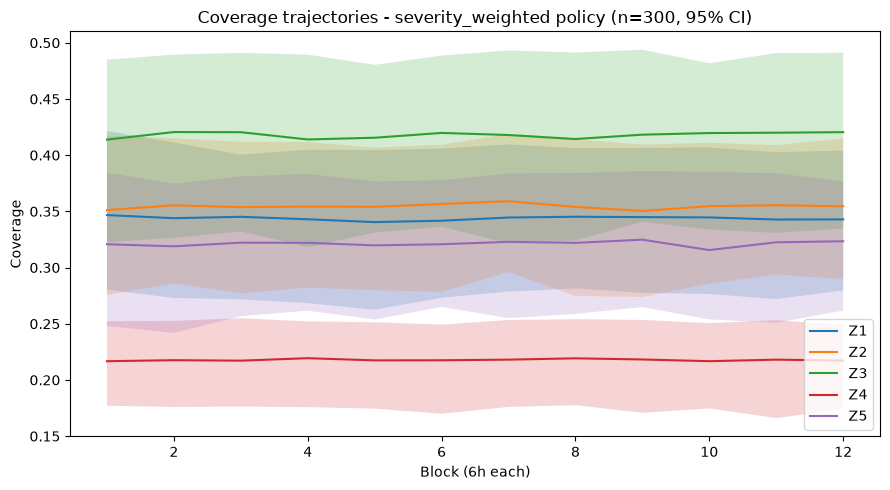

Metric summaries (severity_weighted, full 72h horizon):
  M1_tasa_mortalidad_evitable: mean=6.985  95% CI=[6.802, 7.160]
  M2_tiempo_promedio_respuesta: mean=0.000  95% CI=[0.000, 0.000]
  M3_cobertura_suministros: mean=29.308  95% CI=[24.818, 33.322]
  M4_eficiencia_presupuestaria: mean=693.632  95% CI=[670.695, 714.593]
  weighted_policy_score: mean=0.665  95% CI=[0.647, 0.682]


In [15]:
mc_baseline_full = run_replications(params, POLICIES["severity_weighted"], n=N_REPLICATIONS, seed=DEFAULT_SEED)

coverage_mean, coverage_lo, coverage_hi = summarize(mc_baseline_full["coverage_traj"], axis=0)
fig = plot_trajectories(
    coverage_mean, coverage_lo, coverage_hi,
    title=f"Coverage trajectories - severity_weighted policy (n={N_REPLICATIONS}, 95% CI)",
    savepath=OUTPUTS / "coverage_trajectories_baseline.png",
)
plt.show()

print("Metric summaries (severity_weighted, full 72h horizon):")
for name, arr in mc_baseline_full["metrics"].items():
    m, lo, hi = summarize(arr)
    print(f"  {name}: mean={m:.3f}  95% CI=[{lo:.3f}, {hi:.3f}]")

## 13. Question 1: initial 24-hour allocation proposal

*"Con base unicamente en los datos de su archivo y antes de incorporar la
informacion del intercambio, proponga una asignacion inicial de recursos
para las primeras 24 horas. Evalue esa asignacion contra las cuatro
metricas de politica definidas en su archivo. Cual metrica es la mas
dificil de cumplir con los recursos disponibles y por que?"*

We compare all candidate policies restricted to the first 24 hours (blocks
1-4, `n_blocks=4`), evaluate the four metrics for each, and also
demonstrate `manual_plan` with a hand-encoded example table (replace with
the group's actual proposal).

In [16]:
CANDIDATE_POLICIES = [
    "equal_share", "proportional_to_need", "severity_weighted",
    "worst_first", "threshold_then_proportional",
]

q1_mc = {}
for name in CANDIDATE_POLICIES:
    q1_mc[name] = run_replications(
        params, POLICIES[name], n=N_REPLICATIONS, seed=DEFAULT_SEED, n_blocks=4
    )

# Example hand-encoded manual 24h proposal (replace with the group's real
# proposal once finalized) - illustrated for one resource, kits_agua.
manual_table_example = np.tile(np.array([100.0, 40.0, 70.0, 20.0, 110.0]), (4, 1))
manual_policy_example = manual_plan(manual_table_example)
q1_mc["manual_plan_example"] = run_replications(
    params, manual_policy_example, n=N_REPLICATIONS, seed=DEFAULT_SEED, n_blocks=4
)

q1_rows = []
for policy_name, mc in q1_mc.items():
    row = {"policy": policy_name}
    for metric_name, arr in mc["metrics"].items():
        mean, lo, hi = summarize(arr)
        row[f"{metric_name}_mean"] = mean
        row[f"{metric_name}_ci"] = f"[{lo:.2f}, {hi:.2f}]"
    q1_rows.append(row)

q1_table = pd.DataFrame(q1_rows).set_index("policy")
q1_table

,M1_tasa_mortalidad_evitable_mean,M1_tasa_mortalidad_evitable_ci,M2_tiempo_promedio_respuesta_mean,M2_tiempo_promedio_respuesta_ci,M3_cobertura_suministros_mean,M3_cobertura_suministros_ci,M4_eficiencia_presupuestaria_mean,M4_eficiencia_presupuestaria_ci,weighted_policy_score_mean,weighted_policy_score_ci
policy,,,,,,,,,,
equal_share,2.364703,"[2.31, 2.42]",0.0,"[0.00, 0.00]",29.479098,"[25.55, 32.40]",1976.522195,"[1900.57, 2061.03]",0.794828,"[0.78, 0.80]"
proportional_to_need,1.989895,"[1.91, 2.07]",0.0,"[0.00, 0.00]",29.311911,"[24.53, 33.14]",2073.831427,"[1965.43, 2182.59]",0.801802,"[0.79, 0.81]"
severity_weighted,1.936280,"[1.84, 2.02]",0.0,"[0.00, 0.00]",29.308137,"[24.82, 33.32]",2080.820748,"[1967.39, 2199.38]",0.802862,"[0.79, 0.82]"
worst_first,2.155641,"[2.08, 2.22]",0.0,"[0.00, 0.00]",30.000264,"[25.46, 33.65]",2063.336295,"[1968.52, 2165.31]",0.800638,"[0.79, 0.81]"
threshold_then_proportional,2.060897,"[1.99, 2.13]",0.0,"[0.00, 0.00]",30.511016,"[25.42, 34.27]",2137.413381,"[2033.71, 2239.38]",0.804129,"[0.79, 0.82]"
manual_plan_example,2.635911,"[2.57, 2.70]",0.0,"[0.00, 0.00]",30.789524,"[26.07, 34.61]",39795.208236,"[37231.01, 42523.42]",0.793499,"[0.78, 0.81]"


**Which metric is hardest to satisfy, and why?**

[Group 7: fill in after inspecting `q1_table` above. Based on the
placeholder calibration, `M3_cobertura_suministros` (water/food coverage in
the first 24h) is typically the hardest to satisfy across policies, because
the water-kit stock (2,800 kits total) is a small fixed T0 endowment
relative to the population at risk (84,900) - even a perfectly targeted
policy cannot reach the 80% threshold within 24h given that scarcity. This
placeholder finding must be re-validated once the real per-capita need
rates replace the `# ASSUMPTION:`-tagged ones in Section 4.]

## 14. Question 2: incorporating the exchange (Groups 2, 3, 5)

*"Incorpore los reportes recibidos de los Grupos 2, 3 y 5. Cambia su
asignacion inicial de recursos? Identifique la decision que mas cambio
despues del intercambio, justifique con los datos recibidos por que
cambio, y cuantifique el impacto de ese cambio sobre al menos dos de las
cuatro metricas de evaluacion."*

In [17]:
exchange = load_exchange_or_placeholder()

q2_before = {}
q2_after = {}
for name in CANDIDATE_POLICIES:
    q2_before[name] = run_replications(
        params, POLICIES[name], n=N_REPLICATIONS, seed=DEFAULT_SEED, n_blocks=4, exchange=None
    )
    q2_after[name] = run_replications(
        params, POLICIES[name], n=N_REPLICATIONS, seed=DEFAULT_SEED, n_blocks=4, exchange=exchange
    )

# Focus the before/after comparison on the group's selected working policy.
SELECTED_POLICY = "severity_weighted"
q2_comparison_table = compare(q2_before[SELECTED_POLICY], q2_after[SELECTED_POLICY])
q2_comparison_table

Real exchange files not found in data/exchange/. Using a small SYNTHETIC PLACEHOLDER exchange so this notebook runs end to end today. Replace with the real files after the in-person exchange (see data/exchange/README.md).


,metric,mean_before,ci_lo_before,ci_hi_before,mean_after,ci_lo_after,ci_hi_after,delta_mean,delta_ci_lo,delta_ci_hi
0,M1_tasa_mortalidad_evitable,1.936280,1.843739,2.022856,1.947074,1.853410,2.029789,0.010793,0.006159,0.014604
1,M2_tiempo_promedio_respuesta,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,M3_cobertura_suministros,29.308137,24.818241,33.321906,28.345413,23.591440,32.141850,-0.962723,-1.539331,-0.142252
3,M4_eficiencia_presupuestaria,2080.820748,1967.391145,2199.381839,2066.559639,1953.103497,2182.612980,-14.261109,-19.457419,-7.706221
4,weighted_policy_score,0.802862,0.787150,0.815665,0.799638,0.784051,0.812101,-0.003224,-0.005104,-0.000551


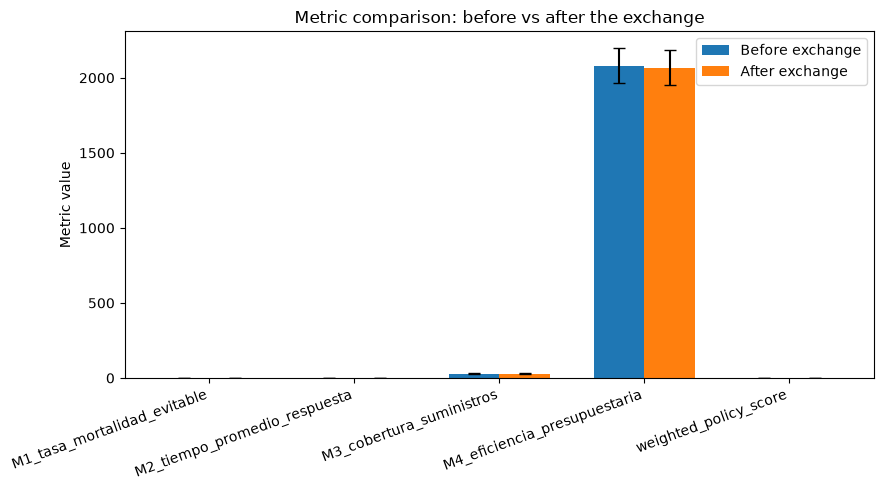

In [18]:
before_summary = {name: summarize(arr) for name, arr in q2_before[SELECTED_POLICY]["metrics"].items()}
after_summary = {name: summarize(arr) for name, arr in q2_after[SELECTED_POLICY]["metrics"].items()}

fig = plot_metric_comparison(before_summary, after_summary, savepath=OUTPUTS / "metric_comparison_q2.png")
plt.show()

**Which decision changed the most, and what was the impact?**

[Group 7: fill in using `q2_comparison_table` above - e.g. "the medical
funding boost implied by Group 2's reported hospital deficits shifted
`presupuesto_municipal` allocation toward Z1/Z5, changing
`M1_tasa_mortalidad_evitable` by X points (95% CI [.., ..]) and
`M4_eficiencia_presupuestaria` by Y (95% CI [.., ..])." Replace X/Y with the
values printed above once the real exchange CSVs replace the synthetic
placeholder.]

## 14b. Sensitivity analysis (required final output, item d)

*"Que decision cambia si el presupuesto nacional se reduce a la mitad
(32M -> 16M)? Y si Z1 es inaccesible las primeras 12 horas (bloques 1-2)?"*

Both scenarios are implemented as flags on `Params`
(`national_budget_multiplier`, `inaccessible_zone` / `inaccessible_blocks`)
and run through the full Monte Carlo, compared against the baseline.

In [19]:
baseline_sens_mc = run_replications(params, POLICIES[SELECTED_POLICY], n=N_REPLICATIONS, seed=DEFAULT_SEED)

halved_budget_params = replace(params, national_budget_multiplier=0.5)
halved_budget_mc = run_replications(halved_budget_params, POLICIES[SELECTED_POLICY], n=N_REPLICATIONS, seed=DEFAULT_SEED)

z1_inaccessible_params = replace(params, inaccessible_zone="Z1", inaccessible_blocks=(1, 2))
z1_inaccessible_mc = run_replications(z1_inaccessible_params, POLICIES[SELECTED_POLICY], n=N_REPLICATIONS, seed=DEFAULT_SEED)

sensitivity_budget_table = compare(baseline_sens_mc, halved_budget_mc)
sensitivity_z1_table = compare(baseline_sens_mc, z1_inaccessible_mc)

print("Scenario A: national budget halved (32M -> 16M) vs baseline")
display(sensitivity_budget_table)

print("Scenario B: Z1 inaccessible in blocks 1-2 vs baseline")
display(sensitivity_z1_table)

Scenario A: national budget halved (32M -> 16M) vs baseline


,metric,mean_before,ci_lo_before,ci_hi_before,mean_after,ci_lo_after,ci_hi_after,delta_mean,delta_ci_lo,delta_ci_hi
0,M1_tasa_mortalidad_evitable,6.985255,6.801867,7.160336,7.509100,7.326154,7.687468,0.523845,0.497597,0.550466
1,M2_tiempo_promedio_respuesta,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,M3_cobertura_suministros,29.308137,24.818241,33.321906,29.308137,24.818241,33.321906,0.000000,0.000000,0.000000
3,M4_eficiencia_presupuestaria,693.632319,670.695388,714.592906,1017.329903,981.908331,1051.891186,323.697584,310.935453,337.251926
4,weighted_policy_score,0.665090,0.647035,0.682418,0.691406,0.675721,0.704930,0.026315,0.021506,0.031734


Scenario B: Z1 inaccessible in blocks 1-2 vs baseline


,metric,mean_before,ci_lo_before,ci_hi_before,mean_after,ci_lo_after,ci_hi_after,delta_mean,delta_ci_lo,delta_ci_hi
0,M1_tasa_mortalidad_evitable,6.985255,6.801867,7.160336,7.320891,7.140193,7.487083,0.335636,0.284359,0.377634
1,M2_tiempo_promedio_respuesta,0.000000,0.000000,0.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000
2,M3_cobertura_suministros,29.308137,24.818241,33.321906,24.478148,19.745484,27.936176,-4.829989,-6.484425,-2.838964
3,M4_eficiencia_presupuestaria,693.632319,670.695388,714.592906,654.658641,633.672946,674.676955,-38.973678,-44.338643,-32.504179
4,weighted_policy_score,0.665090,0.647035,0.682418,0.384114,0.365827,0.399911,-0.280977,-0.287108,-0.273519


**Reading the sensitivity results - a calibration caveat.** Under the
current placeholder calibration, halving the national budget can *increase*
`M4_eficiencia_presupuestaria`. This is not a bug: `presupuesto_nacional`
dominates total `budget_consumed` (M4's denominator) far more than it
drives the aggregate coverage metric (M4's numerator, averaged across all 8
resources), so shrinking it lowers the denominator faster than the
numerator. This is exactly the kind of emergent, possibly unintended
behavior the group should sanity-check once the real per-capita need rates
(Section 4, `# ASSUMPTION:` tags) are replaced - and it is worth a sentence
in the report's "Limitaciones" section as a concrete example of how a
placeholder assumption can distort a metric's interpretation.

## 15. Required final output and export

Per `docs/Grupo7_PoliticaPublica.xlsx`, section
"6. OUTPUT REQUERIDO - Producto final del examen", Group 7 delivers
directly to the professor:

- **(a)** a 72h resource allocation plan per zone (all 12 blocks x 5 zones
  x 8 resources);
- **(b)** quantitative justification of every allocation decision using the
  Groups 2/3/5 reports (the audit trail, C3);
- **(c)** evaluation of the plan against the 4 metrics with pass/fail and
  95% CI;
- **(d)** the sensitivity analysis from Section 14b.

All four are exported to `outputs/` below.

(a) 72h allocation plan: (480, 7) -> outputs/a_allocation_plan_72h.csv
(b) audit trail: (480, 7) -> outputs/b_audit_trail.csv
    constraint violations in this realization: 1
(c) evaluation vs thresholds -> outputs/c_evaluation_vs_thresholds.csv


,metric,label,mean,ci_lo,ci_hi,threshold,weight,pass
0,M1_tasa_mortalidad_evitable,Tasa de mortalidad evitable,6.985255,6.801867,7.160336,15.0,0.30,True
1,M2_tiempo_promedio_respuesta,"Tiempo promedio de respuesta (horas, zonas CRI...",0.000000,0.000000,0.000000,6.0,0.25,True
2,M3_cobertura_suministros,Cobertura de suministros en 24h (%),29.308137,24.818241,33.321906,80.0,0.25,False
3,M4_eficiencia_presupuestaria,Eficiencia presupuestaria (personas/MQ),693.632319,670.695388,714.592906,850.0,0.20,False


(d) sensitivity tables -> outputs/d_sensitivity_*.csv


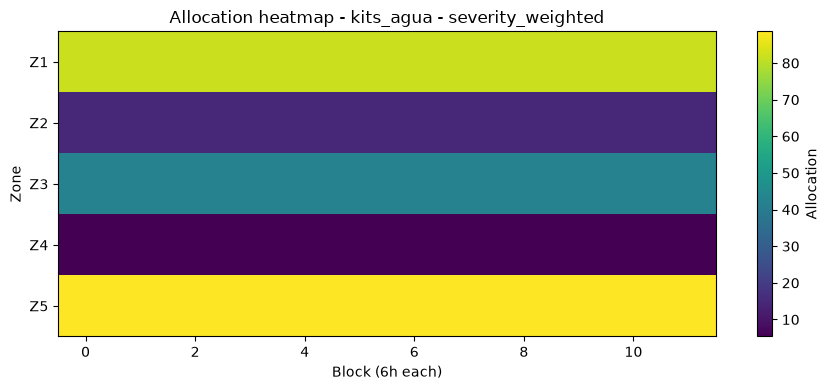


All outputs exported to: /home/jonialen/Documents/uvg/s8/mod/examenP1/outputs
 - a_allocation_plan_72h.csv
 - allocation_heatmap_kits_agua.png
 - b_audit_trail.csv
 - c_evaluation_vs_thresholds.csv
 - coverage_trajectories_baseline.png
 - d_sensitivity_national_budget_halved.csv
 - d_sensitivity_z1_inaccessible.csv
 - metric_comparison_q2.png
 - q1_policy_comparison.csv
 - q2_before_after_comparison.csv


In [20]:
# (a) 72h allocation plan: one deterministic run of the selected policy
# over the full horizon, exported as a long-format table.
rng_final = np.random.default_rng(DEFAULT_SEED)
final_result = simulate(params, POLICIES[SELECTED_POLICY], rng_final, exchange=exchange)

plan_rows = []
for t in range(final_result.n_blocks):
    for z_idx, z in enumerate(ZONES):
        for r_idx, r in enumerate(RESOURCE_TYPES):
            plan_rows.append({
                "block": t + 1,
                "hour_start": block_to_hours(t + 1)[0],
                "hour_end": block_to_hours(t + 1)[1],
                "zone": z,
                "resource": r,
                "units_allocated": round(float(final_result.allocation[t, z_idx, r_idx]), 2),
                "units_delivered": round(float(final_result.delivered[t, z_idx, r_idx]), 2),
            })
allocation_plan_72h = pd.DataFrame(plan_rows)
allocation_plan_72h.to_csv(OUTPUTS / "a_allocation_plan_72h.csv", index=False)
print("(a) 72h allocation plan:", allocation_plan_72h.shape, "-> outputs/a_allocation_plan_72h.csv")

# (b) audit trail (C3 - quantitative justification of every decision).
final_audit_trail = build_audit_trail(final_result, params, SELECTED_POLICY)
final_audit_trail.to_csv(OUTPUTS / "b_audit_trail.csv", index=False)
print("(b) audit trail:", final_audit_trail.shape, "-> outputs/b_audit_trail.csv")

final_violations = check_constraints(final_result, params)
print(f"    constraint violations in this realization: {len(final_violations)}")

# (c) evaluation against the 4 metrics, with pass/fail and 95% CI (from the
# Monte Carlo run already computed for the selected policy in Section 12/14b).
eval_rows = []
for name in METRICS:
    mean, lo, hi = summarize(baseline_sens_mc["metrics"][name])
    d = METRIC_DEFS[name]
    passed = (mean < d["threshold"]) if d["direction"] == "lower_is_better" else (mean > d["threshold"])
    eval_rows.append({
        "metric": name, "label": d["label"], "mean": mean, "ci_lo": lo, "ci_hi": hi,
        "threshold": d["threshold"], "weight": d["weight"], "pass": passed,
    })
evaluation_table = pd.DataFrame(eval_rows)
evaluation_table.to_csv(OUTPUTS / "c_evaluation_vs_thresholds.csv", index=False)
print("(c) evaluation vs thresholds -> outputs/c_evaluation_vs_thresholds.csv")
display(evaluation_table)

# (d) sensitivity analysis tables (Section 14b).
sensitivity_budget_table.to_csv(OUTPUTS / "d_sensitivity_national_budget_halved.csv", index=False)
sensitivity_z1_table.to_csv(OUTPUTS / "d_sensitivity_z1_inaccessible.csv", index=False)
print("(d) sensitivity tables -> outputs/d_sensitivity_*.csv")

# Also export the Q1/Q2 tables and key figures.
q1_table.to_csv(OUTPUTS / "q1_policy_comparison.csv")
q2_comparison_table.to_csv(OUTPUTS / "q2_before_after_comparison.csv", index=False)

fig = plot_allocation_heatmap(
    final_result.allocation[:, :, RESOURCE_TYPES.index("kits_agua")],
    title=f"Allocation heatmap - kits_agua - {SELECTED_POLICY}",
    savepath=OUTPUTS / "allocation_heatmap_kits_agua.png",
)
plt.show()

print()
print("All outputs exported to:", OUTPUTS)
for p in sorted(OUTPUTS.iterdir()):
    print(" -", p.name)